# 🏦 Loan Default Prediction Using Machine Learning
by MARUTI NANDAN


## Step 1 — Install Libraries

In [3]:
!pip -q install xgboost imbalanced-learn seaborn shap

## Step 2 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import shap

## Step 3 — Load Dataset

In [4]:
df = pd.read_csv('Loan_default.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


In [5]:
print('Shape:', df.shape)
print('\nMissing Values:\n', df.isnull().sum())
df.describe()

Shape: (43121, 18)

Missing Values:
 LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       1
HasDependents     1
LoanPurpose       1
HasCoSigner       1
Default           1
dtype: int64


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,43121.000000,43121.000000,43121.000000,43121.000000,43121.000000,43121.000000,43121.000000,43121.000000,43121.00000,43120.000000
mean,43.525544,82507.635700,127580.621901,574.754273,59.569467,2.496440,13.521967,36.000835,0.50306,0.116605
std,14.973621,39019.086431,70846.173662,158.721387,34.614321,1.119296,6.638896,16.893544,0.23044,0.320953
min,18.000000,15000.000000,5005.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.10000,0.000000
25%,31.000000,48665.000000,66275.000000,437.000000,29.000000,1.000000,7.790000,24.000000,0.31000,0.000000
50%,43.000000,82571.000000,127577.000000,575.000000,60.000000,2.000000,13.560000,36.000000,0.51000,0.000000
75%,56.000000,116076.000000,189122.000000,712.000000,89.000000,3.000000,19.260000,48.000000,0.70000,0.000000
max,69.000000,149997.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.90000,1.000000


## Step 4 — Data Cleaning

In [6]:
# Drop identifier column if present
if 'LoanID' in df.columns:
    df.drop('LoanID', axis=1, inplace=True)

# Fill numeric missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode categorical features
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0.0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,2,0,0,4,1,0.0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1.0
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,2,0,0,1,0,0.0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0.0


## Step 5 — Feature Engineering

In [7]:
if 'LoanAmount' in df.columns and 'Income' in df.columns:
    df['Debt_to_Income'] = df['LoanAmount'] / (df['Income'] + 1)

if 'LoanAmount' in df.columns and 'CreditScore' in df.columns:
    df['Loan_to_Credit'] = df['LoanAmount'] / (df['CreditScore'] + 1)

df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Debt_to_Income,Loan_to_Credit
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0.0,0.588255,97.095969
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,2,0,0,4,1,0.0,2.467432,271.111111
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1.0,1.534135,285.814159
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,2,0,0,1,0,0.0,1.412594,60.213710
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0.0,0.447157,14.414826


## Step 8 — Check Class Balance

In [8]:
df['Default'].value_counts()

,count
Default,
0.0,38093
1.0,5028


## Step 6 — Train-Test Split

In [9]:
target = 'Default'
X = df.drop(target, axis=1)
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

## Step 7 — Handle Imbalanced Data

In [10]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print('Before:', np.bincount(y_train))
print('After:', np.bincount(y_train_balanced))

Before: [30436  4060]
After: [30436 30436]


## Step 8 — Logistic Regression

In [11]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_balanced, y_train_balanced)

lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:,1]


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_balanced, y_train_balanced)


LogisticRegression(max_iter=1000)

##**step 9 - confusion_matrix**

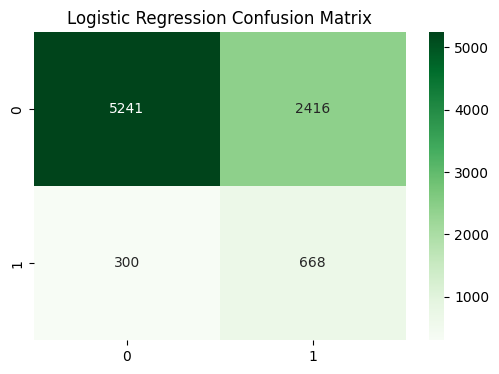

              precision    recall  f1-score   support

         0.0       0.95      0.68      0.79      7657
         1.0       0.22      0.69      0.33       968

    accuracy                           0.69      8625
   macro avg       0.58      0.69      0.56      8625
weighted avg       0.86      0.69      0.74      8625

Logistic Regression ROC-AUC: 0.763064937069413


In [13]:
lr_cm = confusion_matrix(y_test, lr_preds)
plt.figure(figsize=(6,4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

print(classification_report(y_test, lr_preds))
lr_auc = roc_auc_score(y_test, lr_probs)
print('Logistic Regression ROC-AUC:', lr_auc)

## Step 10 — XGBoost

In [14]:
params = {'n_estimators':[200],'max_depth':[6,10],'learning_rate':[0.05,0.1]}

grid = GridSearchCV(XGBClassifier(eval_metric='logloss'),params,cv=3,scoring='roc_auc',n_jobs=-1)

grid.fit(X_train_balanced, y_train_balanced)

best_model = grid.best_estimator_
preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:,1]

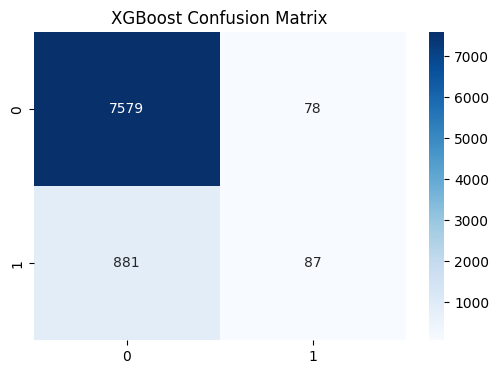

              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94      7657
         1.0       0.53      0.09      0.15       968

    accuracy                           0.89      8625
   macro avg       0.71      0.54      0.55      8625
weighted avg       0.85      0.89      0.85      8625

XGBoost ROC-AUC: 0.734625692258043


In [15]:
xgb_cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,4))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()

print(classification_report(y_test, preds))
xgb_auc = roc_auc_score(y_test, probs)
print('XGBoost ROC-AUC:', xgb_auc)

## Step 11 — ROC Curve Comparison

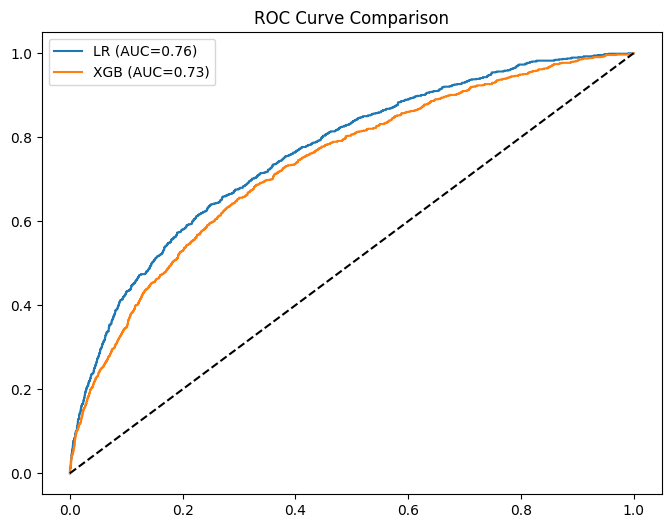

In [16]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label=f'LR (AUC={lr_auc:.2f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGB (AUC={xgb_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title('ROC Curve Comparison')
plt.show()

## Step 12 — Feature Importance

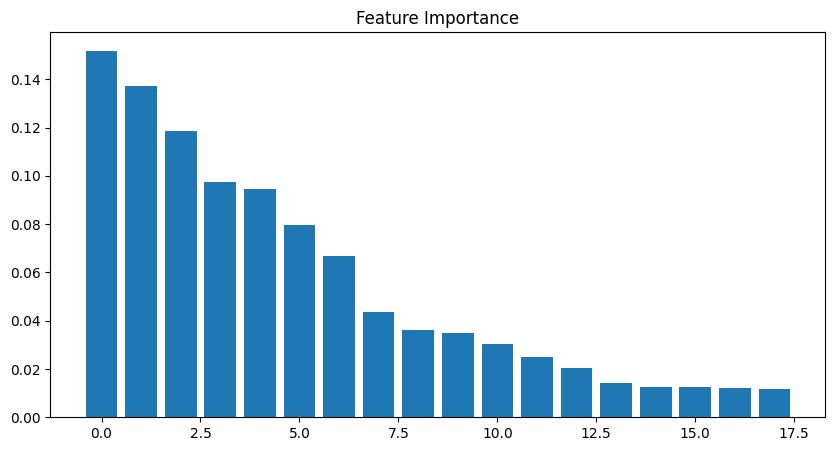

In [17]:
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances[indices])
plt.title('Feature Importance')
plt.show()

## Step 13 — SHAP Explainability

In [ ]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test[:1000])
shap.plots.beeswarm(shap_values)